# Fase 7: Partición temporal y protocolo experimental

Para **forecasting** se exige **orden temporal estricto**:

- **Train:** 2000-01-01 -> 2019-12-31 (aprende todo: scaler, modelo)
- **Validation:** 2020-01-01 -> 2022-12-31 (selección de modelos/hiperparámetros)
- **Test:** 2023-01-01 -> 2025-09-12 (**bloqueado**, solo se usa una vez al final)

Además se elimina el *warm-up*: las primeras filas no tienen lags/rolling
completos (máx. ventana 126 días + huecos de exógenas) y se descartan
ANTES de particionar (evita contaminación).

## Protocolo experimental

1. Los índices de partición se guardan (no se re-generan).
2. Nunca se toca test durante tuning.
3. CV: `TimeSeriesSplit(5 folds, gap=21)` sobre train+val.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import path_from_root, set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga de features y eliminación del warm-up.

`drop_warmup` calcula el número de filas iniciales sin lags completos
(por feature: máximo primer-índice-no-NaN, cubriendo ventanas de 126 días
y huecos de exógenas como us_gdp) y las elimina. Tras esto no debe quedar
ningún NaN en las features.

In [2]:
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup
from src.features.build_features import get_feature_columns

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
cols = get_feature_columns(feats, cfg["target"]["horizons"])
print("Shape tras warm-up:", feats.shape)
print("NaN en features tras warm-up:", int(feats[cols].isna().sum().sum()))

Shape tras warm-up: (6424, 133)
NaN en features tras warm-up: 0


Partición temporal estricta.

`temporal_split` divide por fechas (sin aleatoriedad): train 2000-2019,
val 2020-2022, test 2023-2025. Se guardan las particiones en parquet para
las fases siguientes y se verifica que no hay solape temporal.

In [3]:
from src.data.split import temporal_split

parts = temporal_split(feats, cfg)
for k, v in parts.items():
    print(f"{k:6s}: {len(v):5d} filas | {v['date'].min().date()} -> {v['date'].max().date()}")
    v.to_parquet(path_from_root("data/processed", f"{k}.parquet"), index=False)

tr, va, te = (parts[k]["date"] for k in ("train", "val", "test"))
assert tr.max() < va.min() and va.max() < te.min(), "Solape entre particiones"
print("\nSin solape temporal: OK")

train :  4957 filas | 2001-01-01 -> 2019-12-31
val   :   783 filas | 2020-01-01 -> 2022-12-30


test  :   684 filas | 2023-01-02 -> 2025-08-14



Sin solape temporal: OK


Visualización de la partición temporal.

Gráfico con el precio del oro coloreado por partición (train/val/test).
Muestra que test cubre el rally 2023-2025 (fuera de la distribución de
train), lo que anticipa el reto de generalización.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\split_temporal.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/split_temporal.png')

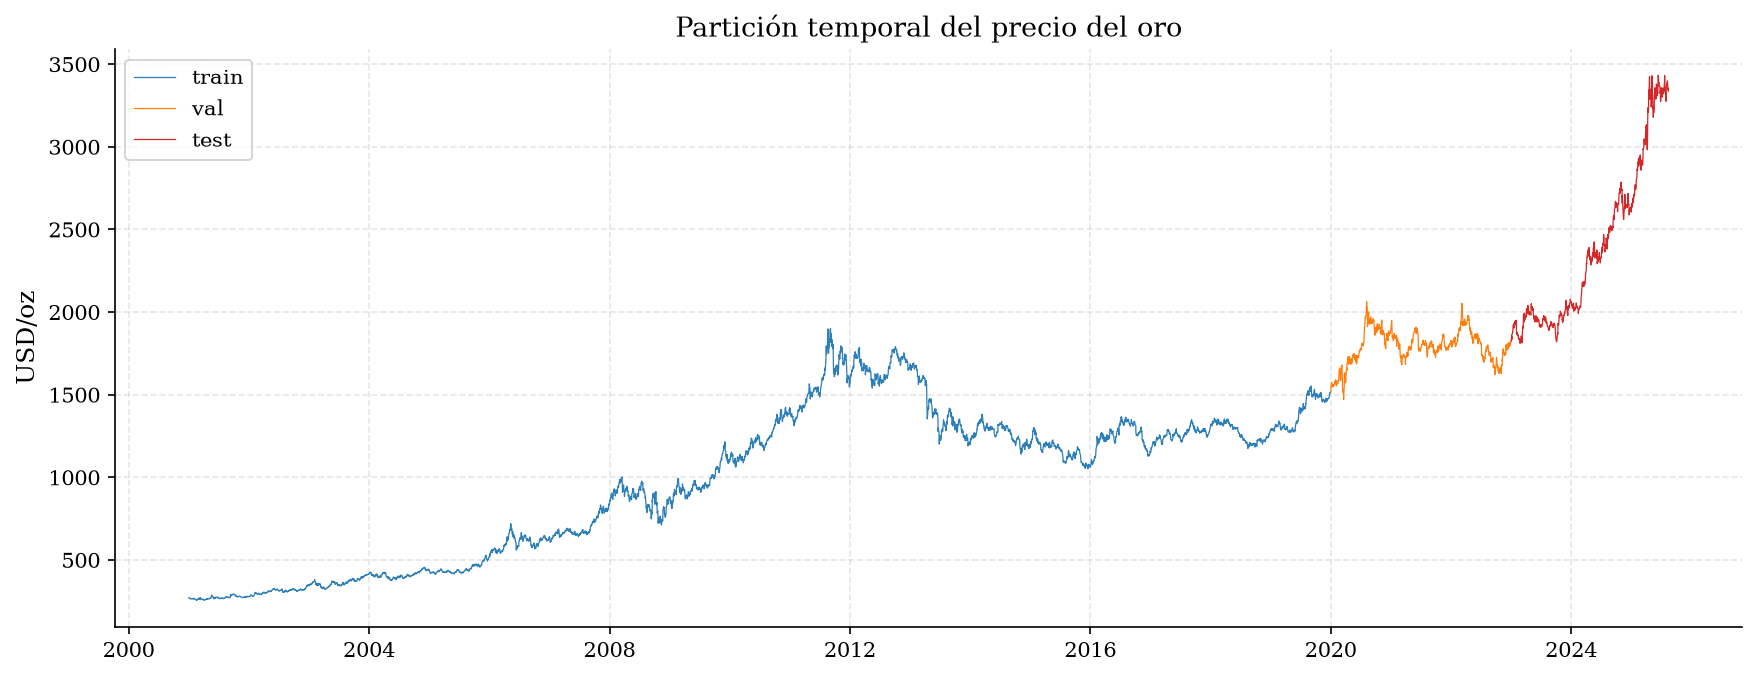

In [4]:
import matplotlib.pyplot as plt

from src.utils import save_fig

fig, ax = plt.subplots(figsize=(14, 5))
colors = {"train": "#2c7fb8", "val": "#ff7f0e", "test": "#d62728"}
for k, v in parts.items():
    ax.plot(v["date"], v["gold_spot"], lw=0.6, color=colors[k], label=k)
ax.set_title("Partición temporal del precio del oro")
ax.set_ylabel("USD/oz")
ax.legend()
save_fig(fig, "split_temporal.png")

Configuración de TimeSeriesSplit para CV.

`TimeSeriesSplit(5, gap=21)` crea 5 folds crecientes sobre train+val con un
hueco de 21 días hábiles entre train y validación de cada fold (evita que
los lags de 21 días del final del train se solapen con el inicio del val).

In [5]:
from src.data.split import get_temporal_splitter

tscv = get_temporal_splitter(cfg)
all_dates = pd.concat([tr, va]).sort_values()
n = len(all_dates)
print(f"TimeSeriesSplit({tscv.n_splits} folds, gap={tscv.gap}) sobre {n} filas:")
for i, (tr_idx, va_idx) in enumerate(tscv.split(range(n))):
    print(f"  fold {i}: train {len(tr_idx):5d} | val {len(va_idx):5d}")

TimeSeriesSplit(5 folds, gap=21) sobre 5740 filas:
  fold 0: train   939 | val   956
  fold 1: train  1895 | val   956
  fold 2: train  2851 | val   956
  fold 3: train  3807 | val   956
  fold 4: train  4763 | val   956
